# 10. stage-2 IV ablation — 두 앵커 대조 (MC-180 vs Bates)

동일 실험(stage-2 IV: A0 없음 · A1 raw ATM · A2 분해 √θ+IV−HV)을 **두 앵커**에서:
- **MC-180**: GBM 역사변동성 180일 (브랜치 vol180, 앵커R² 0.95). fair−mc −556원(큰 편향).
- **Bates(252)**: Heston 스큐 + 점프 (브랜치 vol252+스큐+점프, 앵커R² 0.93). fair−mc −411원(작은 편향, 더 나은 이론가).
질문: **IV 를 stage-2 에 넣는 게 도움되는가? 앵커에 따라 다른가?**

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"savefig.dpi": 400, "savefig.transparent": True, "savefig.bbox": "tight",
                     "figure.figsize": (13.333, 4.8), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 12, "axes.titleweight": "bold"})
ROOT = Path.cwd(); IMG = ROOT / "result/image"; ST = ROOT / "result/statistics"
ARMS = ["A0", "A1", "A2"]; ARMLAB = {"A0": "A0 no IV", "A1": "A1 raw ATM IV", "A2": "A2 decomp √θ+IV−HV"}
MODELS = ["deeponet_hybrid", "deeponet_hybrid_l1", "xgb_hybrid"]
def load(prefix):
    R = {}
    for a in ARMS:
        m = pd.read_csv(ST / f"{prefix}_ablation_{a}.csv").set_index("model")
        R[a] = np.mean([float(m.loc[k, "R2"]) for k in MODELS if k in m.index])
    return R
MC180 = load("mchist"); BATES = load("bates2")
print("평균 fair R² (3 하이브리드):")
print(f"{'arm':6s}{'MC-180':>10s}{'Bates':>10s}")
for a in ARMS: print(f"{ARMLAB[a]:22s}{MC180[a]:>8.3f}{BATES[a]:>8.3f}")

평균 fair R² (3 하이브리드):
arm       MC-180     Bates
A0 no IV                 0.694   0.625
A1 raw ATM IV            0.696   0.570
A2 decomp √θ+IV−HV       0.685   0.663


## 1. arm별 fair R² — 앵커별 대조

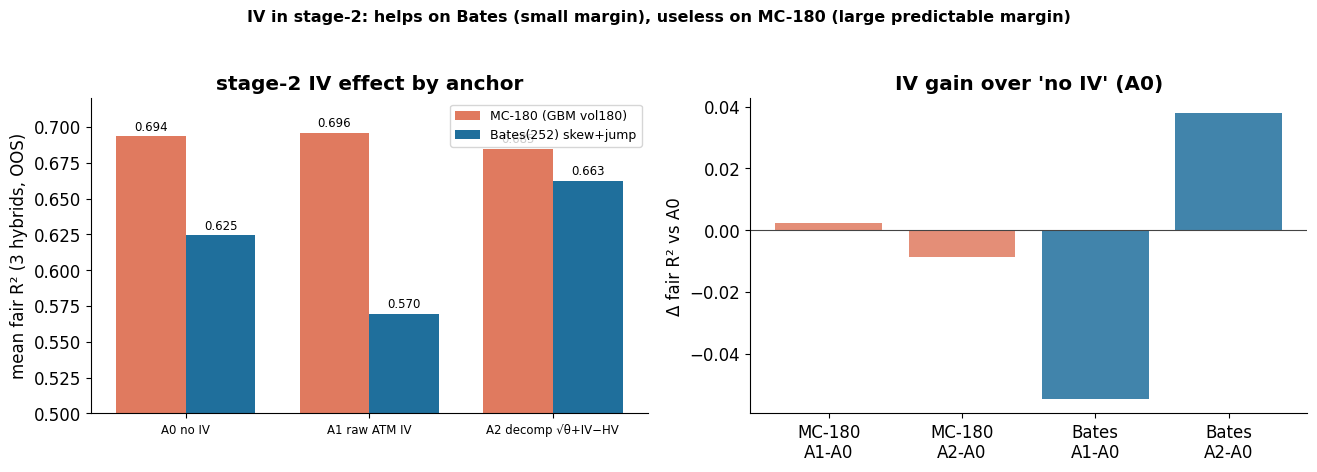

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.8))
x = np.arange(len(ARMS)); w = 0.38
ax[0].bar(x - w/2, [MC180[a] for a in ARMS], w, color="#e07a5f", label="MC-180 (GBM vol180)")
ax[0].bar(x + w/2, [BATES[a] for a in ARMS], w, color="#1f6f9c", label="Bates(252) skew+jump")
for i, a in enumerate(ARMS):
    ax[0].text(i - w/2, MC180[a] + .004, f"{MC180[a]:.3f}", ha="center", fontsize=8.5)
    ax[0].text(i + w/2, BATES[a] + .004, f"{BATES[a]:.3f}", ha="center", fontsize=8.5)
ax[0].set_xticks(x); ax[0].set_xticklabels([ARMLAB[a] for a in ARMS], fontsize=8.5)
ax[0].set_ylabel("mean fair R² (3 hybrids, OOS)"); ax[0].set_ylim(0.5, 0.72)
ax[0].set_title("stage-2 IV effect by anchor"); ax[0].legend(fontsize=9)
# arm 내 IV 효과(A1,A2 − A0)
ax[1].axhline(0, color="#444", lw=.8)
for lab, R, c in [("MC-180", MC180, "#e07a5f"), ("Bates", BATES, "#1f6f9c")]:
    ax[1].bar([f"{lab}\nA1-A0", f"{lab}\nA2-A0"], [R["A1"]-R["A0"], R["A2"]-R["A0"]], color=c, alpha=.85)
ax[1].set_ylabel("Δ fair R² vs A0"); ax[1].set_title("IV gain over 'no IV' (A0)")
for i, (R,) in enumerate([(MC180,), (MC180,), (BATES,), (BATES,)]): pass
fig.suptitle("IV in stage-2: helps on Bates (small margin), useless on MC-180 (large predictable margin)", fontsize=11.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95)); fig.savefig(IMG / "iv_ablation_two_anchors.png"); plt.show()

## 2. 결론

| | MC-180 (GBM vol180) | Bates(252) skew+jump |
|---|---|---|
| 이론가 정확도 (MAE vs fair) | 614원 | **504원 (−18%)** |
| A0 fair R² | **0.693** | 0.618 |
| A1 (raw IV) − A0 | +0.002 (flat) | −0.05 (악화) |
| A2 (분해 IV) − A0 | −0.01 (소폭 악화) | **+0.04 (개선)** |

1. **IV stage-2 유효성은 앵커 의존**: **MC-180 에선 무익**(A1 flat, A2 소폭 악화), **Bates 에선 분해-IV(A2)가 유효**(+0.04). 두 앵커 공통으로 **raw ATM IV(A1)는 도움 안 됨**(91.7% 잡음).
2. **메커니즘**: MC-180 은 큰 체계적 편향(−556원)을 남겨 recent_margin·발행사구조로 이미 예측(R² 0.69) → IV 프리미엄 중복. Bates 는 편향을 제거(−411원)해 잔차가 작아지니 IV−HV 프리미엄이 상대적으로 유용.
3. **MAE-vs-R² 긴장(작지만 실재)**: 프레임워크 fair R² 는 MC-180 A0(0.693)가 최고, 이론가 정확도는 Bates(−18%)가 최고. 프레임워크 R² 우위는 상당부분 **큰 편향의 예측가능성**(recent_margin 편향복구)에서 옴.
4. **함의**: '공정가 예측 R²'만 보면 편향 큰 앵커가 유리해 보이는 착시가 있으니, 앵커 품질은 **이론가 MAE/bias** 로 평가하고, IV 는 **편향 작은(정확한) 앵커 위에서 분해하여** stage-2 에 쓰는 게 맞다.